## Use of AI

ChatGPT was used as a support tool during the development of this project. It was used to help structure parts of the notebook, troubleshoot code issues, and improve parts of the data analysis workflow.

All code, analysis steps, visualizations, and conclusions were reviewed, tested, and modified as needed before being included in the final notebook. The final project reflects my own understanding of the dataset and the analysis process.

## API Connection: Local Ollama Model

For the supplementary API requirement, I connected the notebook to a local Ollama API running on my computer. I used the Gemma 2B model to review a sample of the cleaned Austin weather data and generate suggestions about data quality, possible patterns, and useful analysis directions.

This API connection is not the primary data source. Instead, it supports the analysis by helping summarize potential issues and ideas after the dataset has already been cleaned.

### Import Libraries and Load Dataset

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import requests
import json
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)

DATA_PATH = "austin_weather.csv"

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

weather_raw = pd.read_csv(DATA_PATH)

weather_raw.to_csv(OUTPUT_DIR / "raw_austin_weather.csv", index=False)

print("Dataset shape:", weather_raw.shape)
display(weather_raw.head())


 

Dataset shape: (1319, 21)


,Date,TempHighF,TempAvgF,TempLowF,DewPointHighF,DewPointAvgF,DewPointLowF,HumidityHighPercent,HumidityAvgPercent,HumidityLowPercent,SeaLevelPressureHighInches,SeaLevelPressureAvgInches,SeaLevelPressureLowInches,VisibilityHighMiles,VisibilityAvgMiles,VisibilityLowMiles,WindHighMPH,WindAvgMPH,WindGustMPH,PrecipitationSumInches,Events
0,2013-12-21,74,60,45,67,49,43,93,75,57,29.86,29.68,29.59,10,7,2,20,4,31,0.46,"Rain , Thunderstorm"
1,2013-12-22,56,48,39,43,36,28,93,68,43,30.41,30.13,29.87,10,10,5,16,6,25,0,
2,2013-12-23,58,45,32,31,27,23,76,52,27,30.56,30.49,30.41,10,10,10,8,3,12,0,
3,2013-12-24,61,46,31,36,28,21,89,56,22,30.56,30.45,30.3,10,10,7,12,4,20,0,
4,2013-12-25,58,50,41,44,40,36,86,71,56,30.41,30.33,30.27,10,10,7,10,2,16,T,


# Data Loading and Raw Data Export Explained

The dataset was loaded from the `austin_weather.csv` file into the notebook. A raw copy of the dataset was immediately exported to the `outputs` folder as `raw_austin_weather.csv`.

This makes the project reproducible because someone reviewing the notebook can use the exported raw CSV file without needing to manually load the original data source again.

### Clean and transport data

In [3]:
weather = weather_raw.copy()

weather["Date"] = pd.to_datetime(weather["Date"], errors="coerce")

weather["PrecipitationSumInches"] = (
    weather["PrecipitationSumInches"]
    .astype(str)
    .str.replace("T", "0.001", regex=False)
    .str.strip()
)

for column in weather.columns:
    if column not in ["Date", "Events"]:
        weather[column] = pd.to_numeric(weather[column], errors="coerce")

weather["Events"] = weather["Events"].fillna("").astype(str).str.strip()

weather["Year"] = weather["Date"].dt.year
weather["Month"] = weather["Date"].dt.month
weather["MonthName"] = weather["Date"].dt.month_name()

weather["Season"] = weather["Month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall"
})

weather["TempRangeF"] = weather["TempHighF"] - weather["TempLowF"]

weather["RainEvent"] = weather["Events"].str.contains("Rain", case=False, na=False)
weather["ThunderstormEvent"] = weather["Events"].str.contains("Thunderstorm", case=False, na=False)
weather["FogEvent"] = weather["Events"].str.contains("Fog", case=False, na=False)

weather["RainyDay"] = weather["PrecipitationSumInches"] > 0

weather = weather.dropna(subset=["Date"])
weather = weather.sort_values("Date").reset_index(drop=True)

display(weather.head())
display(weather.isna().sum().sort_values(ascending=False).head(15))

,Date,TempHighF,TempAvgF,TempLowF,DewPointHighF,DewPointAvgF,DewPointLowF,HumidityHighPercent,HumidityAvgPercent,HumidityLowPercent,SeaLevelPressureHighInches,SeaLevelPressureAvgInches,SeaLevelPressureLowInches,VisibilityHighMiles,VisibilityAvgMiles,VisibilityLowMiles,WindHighMPH,WindAvgMPH,WindGustMPH,PrecipitationSumInches,Events,Year,Month,MonthName,Season,TempRangeF,RainEvent,ThunderstormEvent,FogEvent,RainyDay
0,2013-12-21,74,60,45,67.0,49.0,43.0,93.0,75.0,57.0,29.86,29.68,29.59,10.0,7.0,2.0,20.0,4.0,31.0,0.460,"Rain , Thunderstorm",2013,12,December,Winter,29,True,True,False,True
1,2013-12-22,56,48,39,43.0,36.0,28.0,93.0,68.0,43.0,30.41,30.13,29.87,10.0,10.0,5.0,16.0,6.0,25.0,0.000,,2013,12,December,Winter,17,False,False,False,False
2,2013-12-23,58,45,32,31.0,27.0,23.0,76.0,52.0,27.0,30.56,30.49,30.41,10.0,10.0,10.0,8.0,3.0,12.0,0.000,,2013,12,December,Winter,26,False,False,False,False
3,2013-12-24,61,46,31,36.0,28.0,21.0,89.0,56.0,22.0,30.56,30.45,30.30,10.0,10.0,7.0,12.0,4.0,20.0,0.000,,2013,12,December,Winter,30,False,False,False,False
4,2013-12-25,58,50,41,44.0,40.0,36.0,86.0,71.0,56.0,30.41,30.33,30.27,10.0,10.0,7.0,10.0,2.0,16.0,0.001,,2013,12,December,Winter,17,False,False,False,True


VisibilityHighMiles           12
VisibilityAvgMiles            12
VisibilityLowMiles            12
DewPointAvgF                   7
DewPointLowF                   7
DewPointHighF                  7
WindGustMPH                    4
SeaLevelPressureLowInches      3
SeaLevelPressureAvgInches      3
SeaLevelPressureHighInches     3
WindHighMPH                    2
HumidityLowPercent             2
HumidityHighPercent            2
HumidityAvgPercent             2
WindAvgMPH                     2
dtype: int64

# Data Cleaning and Transformation Explained

The data was cleaned and transformed before analysis. The `Date` column was converted into datetime format so that the data could be analyzed over time.

The precipitation column contained trace precipitation values written as `"T"`. These were replaced with `0.001` so they could be included in numeric calculations.

New columns were created for year, month, month name, season, temperature range, rainy days, and weather event categories. These transformations make it easier to compare weather patterns across months and seasons.

### Quantitative analysis

In [4]:
summary_stats = weather[[
    "TempHighF",
    "TempAvgF",
    "TempLowF",
    "TempRangeF",
    "HumidityAvgPercent",
    "WindAvgMPH",
    "PrecipitationSumInches"
]].describe()

monthly_summary = weather.groupby("Month", as_index=False).agg(
    AverageTemperatureF=("TempAvgF", "mean"),
    AverageHighTemperatureF=("TempHighF", "mean"),
    AverageLowTemperatureF=("TempLowF", "mean"),
    TotalPrecipitationInches=("PrecipitationSumInches", "sum"),
    RainyDays=("RainyDay", "sum"),
    AverageHumidityPercent=("HumidityAvgPercent", "mean")
)

seasonal_summary = weather.groupby("Season", as_index=False).agg(
    Days=("Date", "count"),
    AverageTemperatureF=("TempAvgF", "mean"),
    TotalPrecipitationInches=("PrecipitationSumInches", "sum"),
    RainyDays=("RainyDay", "sum"),
    ThunderstormDays=("ThunderstormEvent", "sum")
)

season_order = ["Winter", "Spring", "Summer", "Fall"]
seasonal_summary["Season"] = pd.Categorical(
    seasonal_summary["Season"],
    categories=season_order,
    ordered=True
)
seasonal_summary = seasonal_summary.sort_values("Season")

rainy_day_summary = weather.groupby("RainyDay", as_index=False).agg(
    Days=("Date", "count"),
    AverageTemperatureF=("TempAvgF", "mean"),
    AverageHumidityPercent=("HumidityAvgPercent", "mean"),
    AverageWindMPH=("WindAvgMPH", "mean"),
    TotalPrecipitationInches=("PrecipitationSumInches", "sum")
)

weather.to_csv(OUTPUT_DIR / "cleaned_austin_weather.csv", index=False)
summary_stats.to_csv(OUTPUT_DIR / "summary_statistics.csv")
monthly_summary.to_csv(OUTPUT_DIR / "monthly_summary.csv", index=False)
seasonal_summary.to_csv(OUTPUT_DIR / "seasonal_summary.csv", index=False)
rainy_day_summary.to_csv(OUTPUT_DIR / "rainy_day_summary.csv", index=False)

display(summary_stats)
display(monthly_summary)
display(seasonal_summary)
display(rainy_day_summary)

,TempHighF,TempAvgF,TempLowF,TempRangeF,HumidityAvgPercent,WindAvgMPH,PrecipitationSumInches
count,1319.000000,1319.000000,1319.000000,1319.000000,1317.000000,1317.000000,1319.000000
mean,80.862775,70.642911,59.902957,20.959818,66.671982,5.008352,0.114491
std,14.766523,14.045904,14.190648,7.056507,12.463634,2.086450,0.428150
min,32.000000,29.000000,19.000000,2.000000,27.000000,1.000000,0.000000
25%,72.000000,62.000000,49.000000,17.000000,59.000000,3.000000,0.000000
50%,83.000000,73.000000,63.000000,21.000000,67.000000,5.000000,0.000000
75%,92.000000,83.000000,73.000000,25.000000,74.000000,6.000000,0.001000
max,107.000000,93.000000,81.000000,45.000000,97.000000,12.000000,5.200000


,Month,AverageTemperatureF,AverageHighTemperatureF,AverageLowTemperatureF,TotalPrecipitationInches,RainyDays,AverageHumidityPercent
0,1,52.201613,63.137097,40.725806,9.950,38,61.629032
1,2,57.929204,68.849558,46.407080,4.321,30,62.938053
2,3,63.669355,73.943548,52.943548,12.099,49,67.443548
3,4,70.791667,80.933333,60.125000,12.558,52,67.383333
4,5,75.306452,85.024194,65.104839,34.704,67,70.451613
5,6,82.891667,92.116667,72.950000,17.641,44,70.210084
6,7,86.959677,97.806452,75.653226,7.758,22,64.072581
7,8,86.548387,97.322581,75.247312,7.402,19,64.032609
8,9,82.355556,92.677778,71.677778,10.969,32,67.266667
9,10,75.150538,86.118280,63.688172,13.881,23,63.784946


,Season,Days,AverageTemperatureF,TotalPrecipitationInches,RainyDays,ThunderstormDays
3,Winter,341,55.017595,21.346,105,20
1,Spring,368,69.913043,59.361,168,84
2,Summer,337,85.397626,32.801,85,55
0,Fall,273,72.930403,37.506,91,29


,RainyDay,Days,AverageTemperatureF,AverageHumidityPercent,AverageWindMPH,TotalPrecipitationInches
0,False,870,71.488506,61.911290,4.950461,0.000
1,True,449,69.004454,75.875278,5.120267,151.014


# Quantitative Analysis explained

The cleaned dataset was analyzed using descriptive statistics and grouped summaries.

The summary statistics show the overall distribution of temperature, humidity, wind, and precipitation. Monthly summaries show how average temperature and total precipitation change during the year. Seasonal summaries compare weather conditions across winter, spring, summer, and fall.

A rainy day comparison was also created to compare temperature, humidity, wind, and precipitation between rainy and non-rainy days.

### Visual Analysis and Pipeline Image

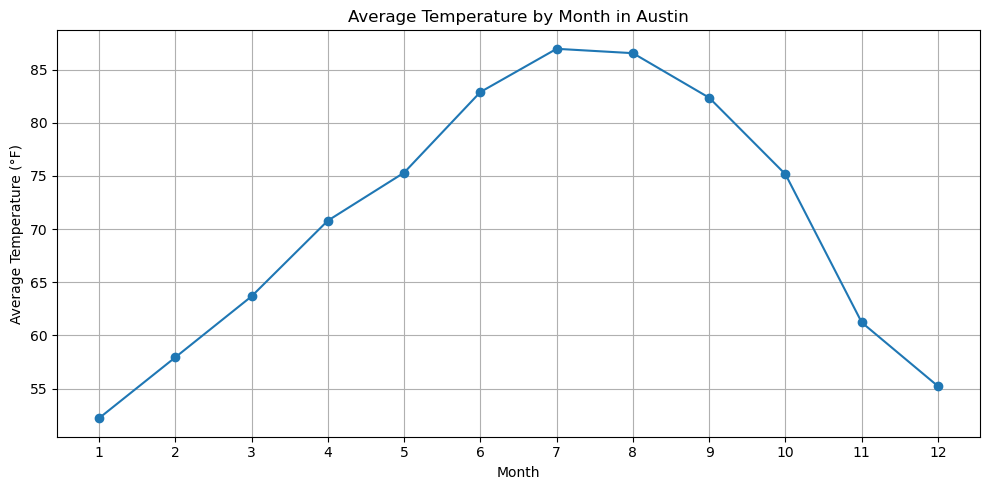

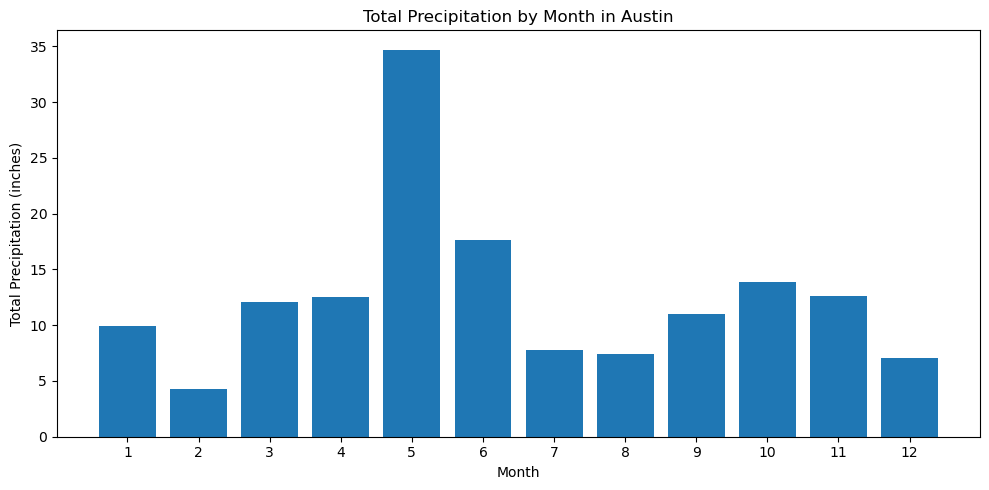

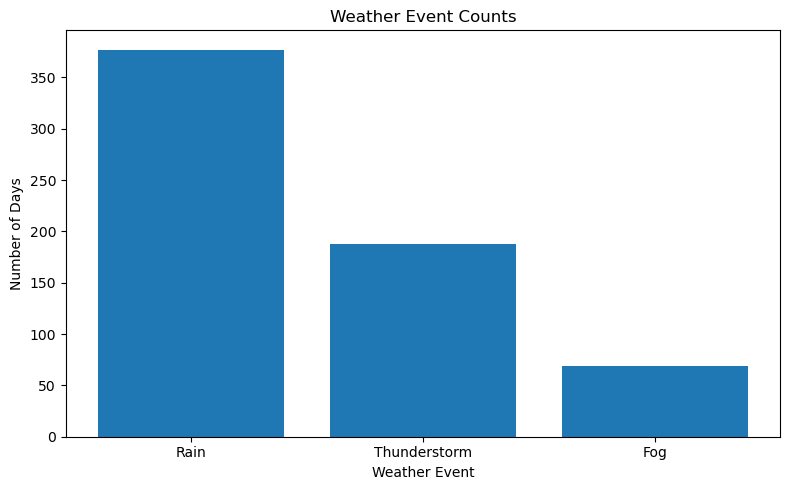

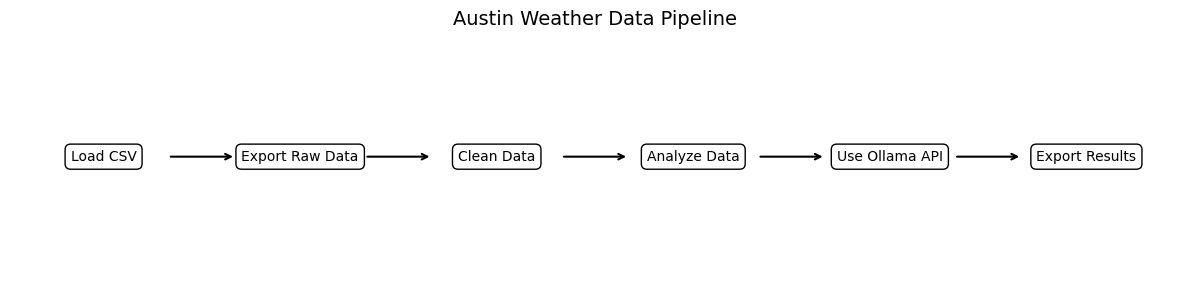

In [5]:
monthly_summary = monthly_summary.sort_values("Month")

plt.figure(figsize=(10, 5))
plt.plot(monthly_summary["Month"], monthly_summary["AverageTemperatureF"], marker="o")
plt.title("Average Temperature by Month in Austin")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°F)")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "average_temperature_by_month.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(monthly_summary["Month"], monthly_summary["TotalPrecipitationInches"])
plt.title("Total Precipitation by Month in Austin")
plt.xlabel("Month")
plt.ylabel("Total Precipitation (inches)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "total_precipitation_by_month.png", dpi=150)
plt.show()

event_counts = pd.Series({
    "Rain": weather["RainEvent"].sum(),
    "Thunderstorm": weather["ThunderstormEvent"].sum(),
    "Fog": weather["FogEvent"].sum()
}).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(event_counts.index, event_counts.values)
plt.title("Weather Event Counts")
plt.xlabel("Weather Event")
plt.ylabel("Number of Days")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "weather_event_counts.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 3))
plt.axis("off")

steps = [
    "Load CSV",
    "Export Raw Data",
    "Clean Data",
    "Analyze Data",
    "Use Ollama API",
    "Export Results"
]

x_positions = np.linspace(0.08, 0.92, len(steps))

for i, step in enumerate(steps):
    plt.text(
        x_positions[i],
        0.5,
        step,
        ha="center",
        va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black")
    )

    if i < len(steps) - 1:
        plt.annotate(
            "",
            xy=(x_positions[i + 1] - 0.055, 0.5),
            xytext=(x_positions[i] + 0.055, 0.5),
            arrowprops=dict(arrowstyle="->", lw=1.5)
        )

plt.title("Austin Weather Data Pipeline", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "data_pipeline_image.png", dpi=150, bbox_inches="tight")
plt.show()

# Visual Analysis and Data Pipeline

The project includes multiple visualizations to support the analysis. The monthly temperature line chart shows how average temperature changes throughout the year. The monthly precipitation bar chart shows which months have the highest total precipitation. The weather event chart compares how often rain, thunderstorms, and fog appear in the dataset.

A pipeline image was also created to visually describe the workflow of the notebook. The pipeline shows the major steps of the project: loading the CSV file, exporting raw data, cleaning the dataset, analyzing the data, using the Ollama API, and exporting the results.

### Ollama API Connection and Final Export List

In [7]:

import requests
import json
from pathlib import Path

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

OLLAMA_BASE_URL = "http://localhost:11434"
OLLAMA_GENERATE_URL = f"{OLLAMA_BASE_URL}/api/generate"

possible_models = [
    "gemma:2b",
    "gemma2:2b",
    "gemma"
]

try:
    test_response = requests.get(f"{OLLAMA_BASE_URL}/api/tags", timeout=10)
    test_response.raise_for_status()

    installed_models = test_response.json().get("models", [])
    installed_model_names = [model["name"] for model in installed_models]

    print("Ollama is running.")
    print("Installed models:", installed_model_names)

    selected_model = None

    for model in possible_models:
        if model in installed_model_names:
            selected_model = model
            break

    if selected_model is None:
        if len(installed_model_names) > 0:
            selected_model = installed_model_names[0]
            print("Gemma 2B was not found. Using first available model:", selected_model)
        else:
            raise Exception("No Ollama models are installed.")

    sample_data = weather.head(5).to_dict(orient="records")

    prompt = f"""
I am analyzing Austin weather data for a data analysis project.

Here are 5 cleaned records from my dataset:

{json.dumps(sample_data, default=str, indent=2)}

Write a short report with:
1. Possible data quality issues
2. Useful analysis ideas
3. Useful visualization ideas
4. Main insights this dataset could show

Keep the response clear and concise.
"""

    payload = {
        "model": selected_model,
        "prompt": prompt,
        "stream": False
    }

    response = requests.post(
        OLLAMA_GENERATE_URL,
        json=payload,
        timeout=180
    )

    response.raise_for_status()

    result = response.json()
    ollama_report = result.get("response", "")

    print("\nOllama API connection succeeded.")
    print("Model used:", selected_model)
    print("\nOllama Report:\n")
    print(ollama_report)

    with open(OUTPUT_DIR / "ollama_gemma_weather_report.txt", "w", encoding="utf-8") as file:
        file.write(ollama_report)

except requests.exceptions.ConnectionError:
    print("Ollama API connection failed.")
    print("Ollama does not appear to be running.")
    print("Open a terminal and run:")
    print("ollama serve")

except requests.exceptions.Timeout:
    print("Ollama API connection failed.")
    print("The request timed out. Try running the cell again or use fewer rows.")

except Exception as error:
    print("Ollama API connection failed.")
    print(error)
    print("\nUseful terminal commands:")
    print("ollama list")
    print("ollama pull gemma:2b")
    print("ollama serve")

Ollama is running.
Installed models: ['gemma:2b', 'llama3:latest']

Ollama API connection succeeded.
Model used: gemma:2b

Ollama Report:

## Data Quality Issues

* **Missing values:** There are several missing values, including precipitation, temperature range, and event categories.
* **Inconsistent formatting:** The date format is inconsistent, with some values using "YYYY-MM-DD" and others using "YYYY-MM-YY".
* **Formatting issues:** Some temperature values seem to have invalid characters or formatting.

## Analysis Ideas

* Analyze the distribution of key variables like temperature, precipitation, and wind speed.
* Explore relationships between variables like temperature and precipitation.
* Investigate the occurrence of rain, thunderstorms, and fog events.
* Analyze how weather patterns might have changed over time.

## Visualization Ideas

* Create a scatter plot of temperature vs. precipitation to identify any trends or correlations.
* Generate a box plot to visualize the distri

### # API Connection and Conclusion

This notebook connects to a local Ollama API using the Gemma 2B model. The API connection is used as a supplementary analysis tool. It reviews a sample of the cleaned weather data and provides suggestions about data quality, weather patterns, possible visualizations, and insights.

The primary data source is the Austin weather CSV file. The Ollama API is not used as the main source of data. Instead, it supports the analysis process after the dataset has already been cleaned.

## Conclusion

This project analyzed Austin weather data using a complete data analysis workflow. The data was loaded from a CSV file, exported as raw data, cleaned, transformed, analyzed quantitatively, visualized, and exported as final result files.

The analysis shows clear seasonal temperature patterns in Austin. Average temperatures are higher during the summer months and lower during the winter months. Precipitation also varies by month, and rainy days can be compared with non-rainy days using humidity, wind, and precipitation measurements.

The project also includes a visual data pipeline and a local API connection through Ollama. Overall, the notebook demonstrates how weather data can be cleaned, analyzed, visualized, and supported with an API-based workflow.